Wybrać zbiór danych

- Przygotować dane do analizy (jeśli są jakieś dane brakujące zastąpić na razie np. wartością średnią, starać się, żeby cechy miały wartości liczbowe, jeśli jakiś zbiór będzie miał cechę textową, można wyrzucić lub zamienić np. one-hot-encoding)
- Zbudować 2-4 modele uczenie maszynowego
- Dla każdego z modeli zastosować 2 metody wyjaśnienia lokalnego (np. Lime/Shap)
- Dla kazdego podobnie metodę wyjaśnienia globalnego (np. feature importance, PDP)
- Przygotować raport porównawczy (czy wyjaśnienia są spójne, które dostarczają ciekawych wyników, czy to zbiega z Państwa interpretacją, jakieś różnice etc)
- Proszę o dogłębne przedstawienie i porównenie tego co wyżej (opis, wykresy)


In [8]:
import pandas as pd
import numpy as np

# Dla wizualizacji i modeli
import matplotlib.pyplot as plt
import seaborn as sns

# Modele ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Wyjaśnialność
import shap
import lime
import lime.lime_tabular

# Ignorowanie ostrzeżeń
import warnings
warnings.filterwarnings('ignore')


In [9]:
df = pd.read_csv("titanic.csv")  # załaduj swój plik CSV

# Usuwamy kolumny mało informacyjne lub trudne do przekształcenia (np. 'Cabin', 'Name', 'Ticket')
df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True)

# Uzupełnianie braków
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Separacja zmiennej celu i cech
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Cechy numeryczne i kategoryczne
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Sex', 'Embarked', 'Pclass']  # Pclass traktujemy jako kategoria

# Pipeline do przetwarzania danych
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=4),
    'SVC': SVC(probability=True)
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('classifier', model)])


In [27]:
print("📊 Wyniki dokładności modeli:")
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} score: {pipe.score(X_test, y_test):.3f}")


📊 Wyniki dokładności modeli:
Logistic Regression score: 0.799
KNN score: 0.810
Decision Tree score: 0.799
SVC score: 0.816


In [28]:
# Fit and transform data
X_preprocessed = preprocessor.fit_transform(X_train)

# Jeśli jest to sparse matrix — zamieniamy
X_lime = X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed

# SHAP Explainer
model_lr = LogisticRegression().fit(X_preprocessed, y_train)
explainer_shap = shap.Explainer(model_lr.predict_proba, X_preprocessed)

# LIME Explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_lime,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['Not Survived', 'Survived'],
    mode='classification'
)




======================= Model: Logistic Regression =======================
🔍 SHAP Waterfall Plot


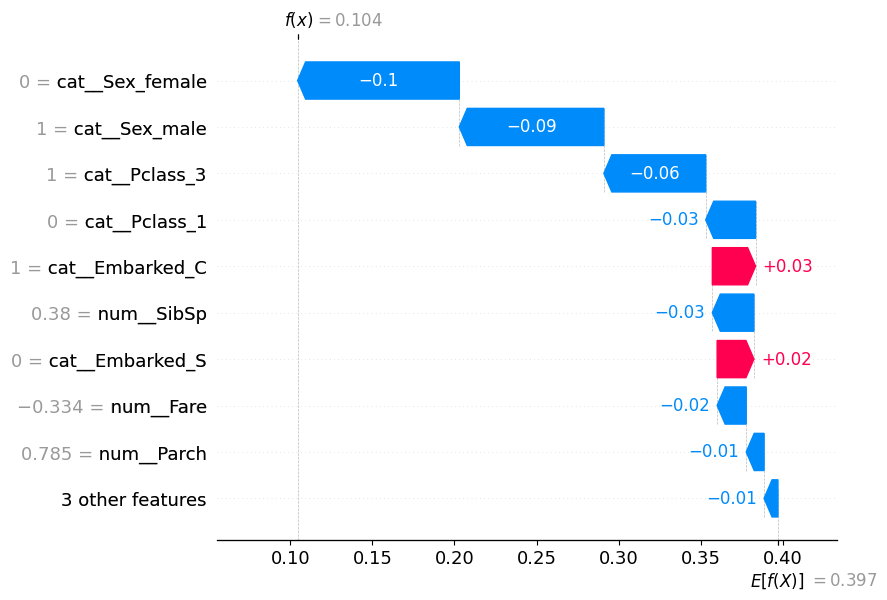

🔍 LIME Explanation


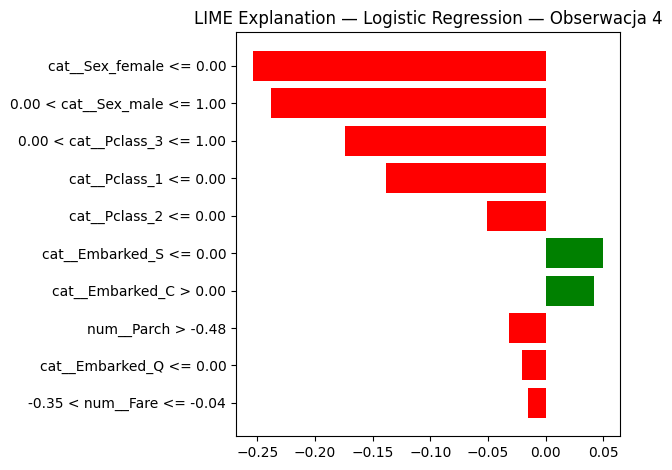



======================= Model: KNN =======================
🔍 SHAP Waterfall Plot


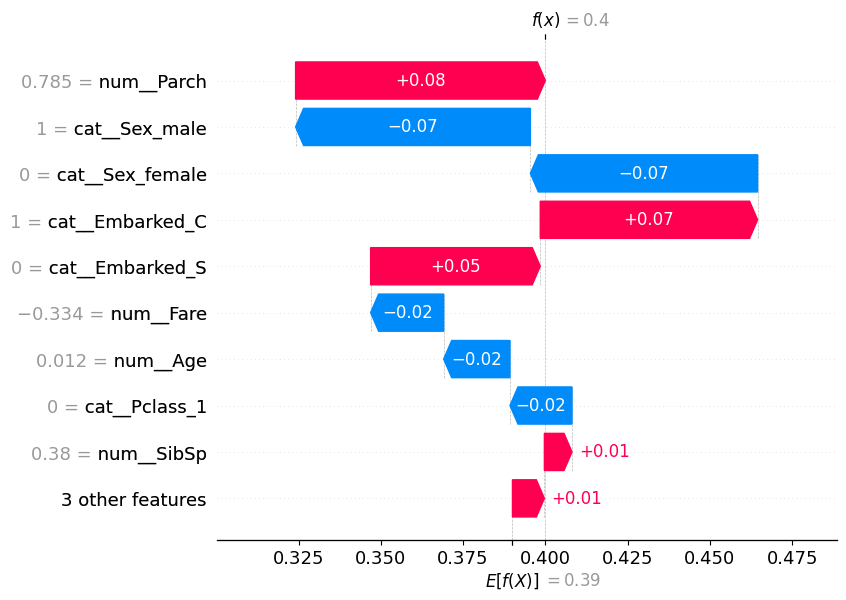

🔍 LIME Explanation


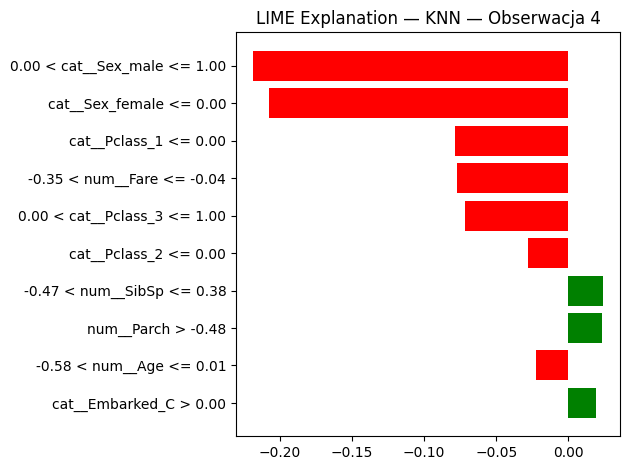



======================= Model: Decision Tree =======================
🔍 SHAP Waterfall Plot


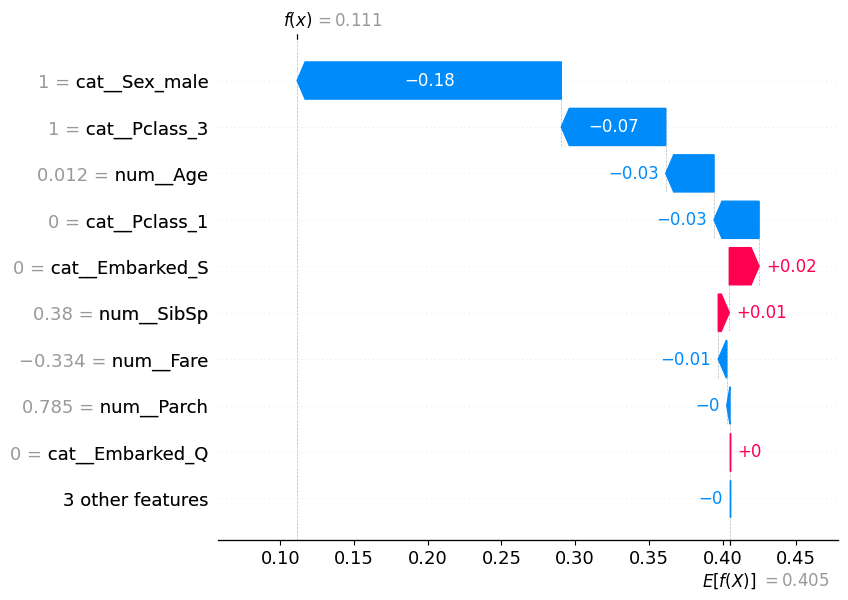

🔍 LIME Explanation


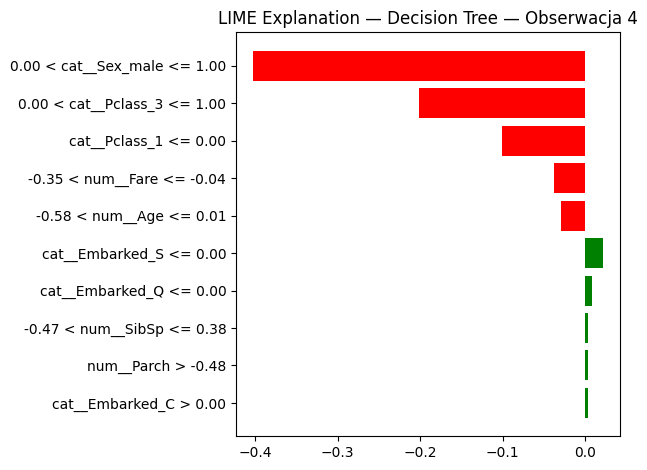



======================= Model: SVC =======================
🔍 SHAP Waterfall Plot


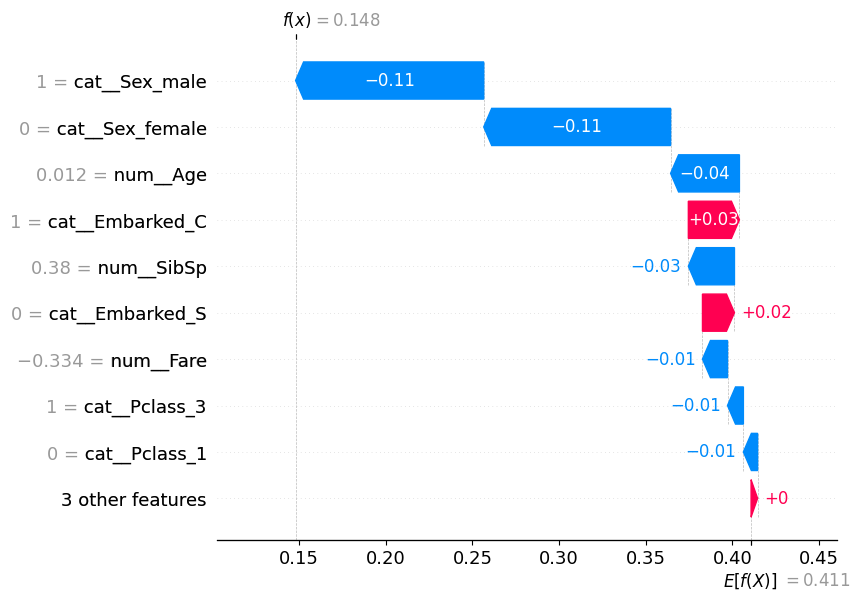

🔍 LIME Explanation


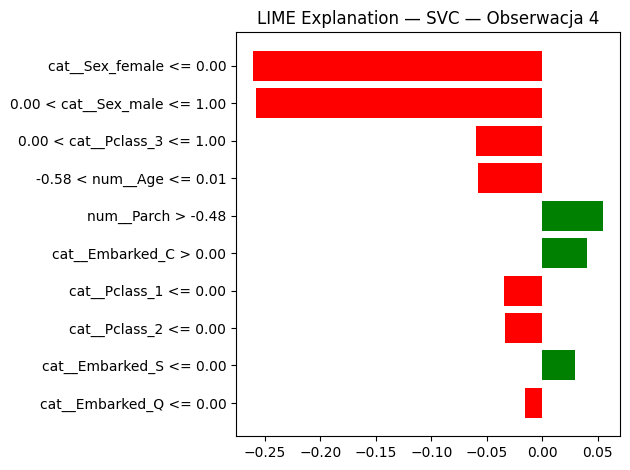

In [34]:
from IPython.display import display
import matplotlib.pyplot as plt
import shap
import lime.lime_tabular

shap.initjs()

for model_name in models:
    print(f"\n\n======================= Model: {model_name} =======================")
    
    pipeline = pipelines[model_name]
    model = pipeline.named_steps['classifier']
    preprocessor = pipeline.named_steps['preprocessor']
    
    # Dane treningowe przetworzone - dla LIME
    X_train_pre = preprocessor.fit_transform(X_train)
    X_train_array = X_train_pre.toarray() if hasattr(X_train_pre, "toarray") else X_train_pre
    feature_names = preprocessor.get_feature_names_out()
    
    # Inicjalizacja LIME tylko raz
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_array,
        feature_names=feature_names,
        class_names=['Not Survived', 'Survived'],
        mode='classification'
    )
    
    # Inicjalizacja SHAP tylko raz
    shap_explainer = shap.Explainer(model.predict_proba, X_train_array)

    
    # 1. Pobranie i przetworzenie obserwacji
    sample = X_test.iloc[[0]]
    sample_pre = preprocessor.transform(sample)
    sample_array = sample_pre.toarray() if hasattr(sample_pre, "toarray") else sample_pre

    # === SHAP ===
    print("🔍 SHAP Waterfall Plot")
    shap_values = shap_explainer(sample_array)
    shap.plots.waterfall(shap.Explanation(
        values=shap_values.values[0][:, 1],
        base_values=shap_values.base_values[0][1],
        data=shap_values.data[0],
        feature_names=feature_names
    ), max_display=10)

    # === LIME ===
    print("🔍 LIME Explanation")
    exp = lime_explainer.explain_instance(
        sample_array[0],
        model.predict_proba,
        num_features=10
    )
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation — {model_name} — Obserwacja {i}")
    plt.tight_layout()
    plt.show()


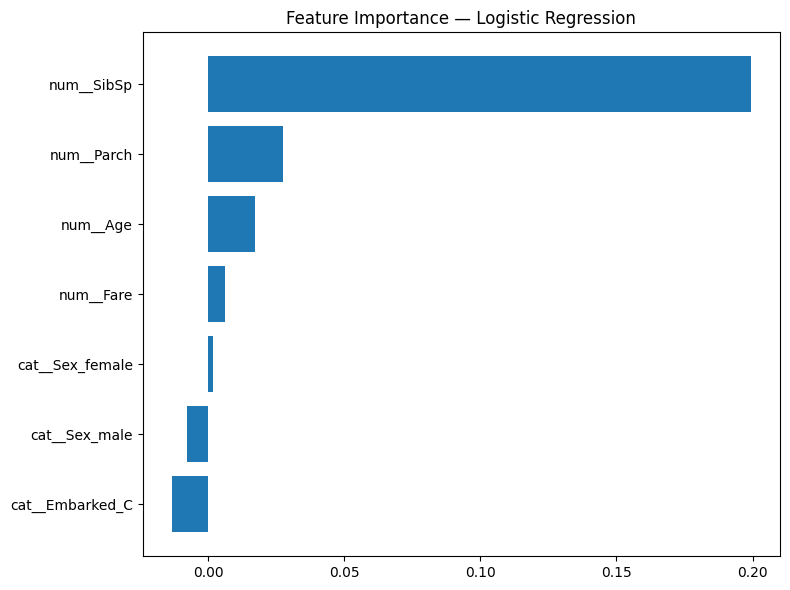

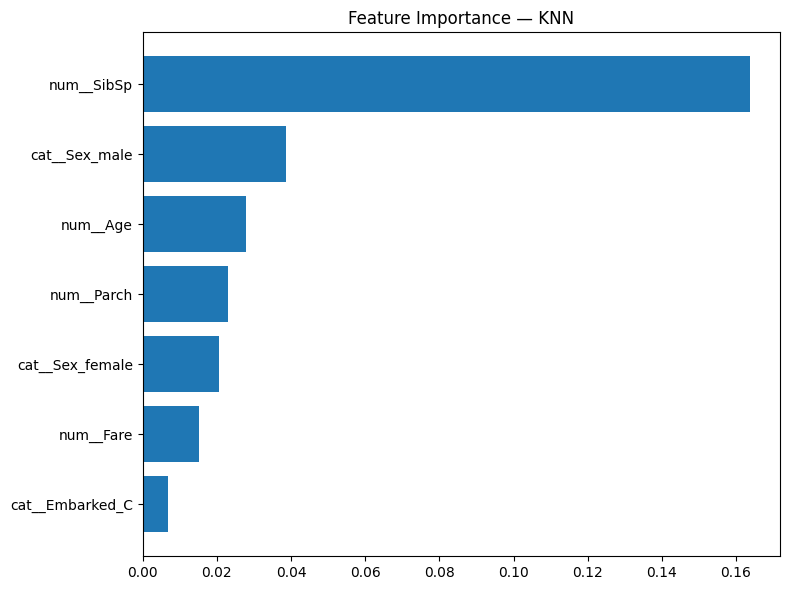

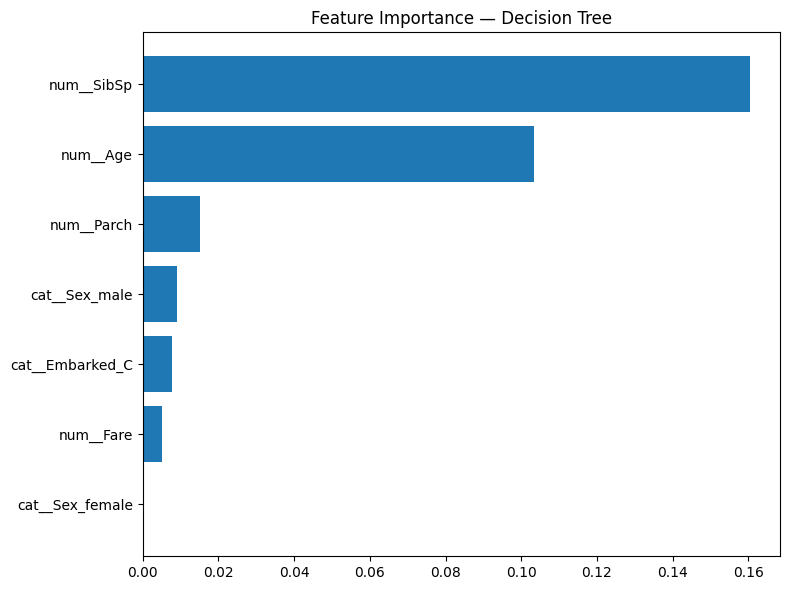

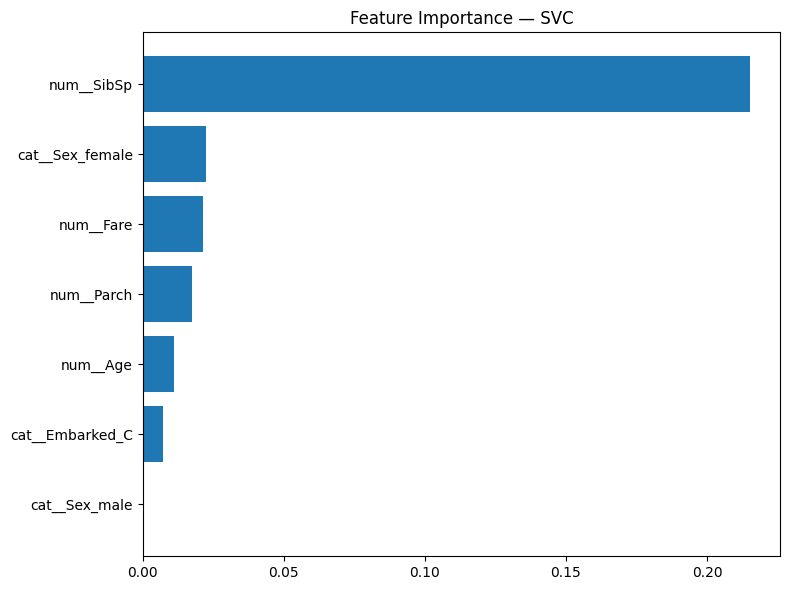

In [35]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

def plot_feature_importance(model_name):
    model = pipelines[model_name]
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    sorted_idx = result.importances_mean.argsort()
    feature_names = model.named_steps['preprocessor'].get_feature_names_out()

    plt.figure(figsize=(8, 6))
    plt.barh(np.array(feature_names)[sorted_idx], result.importances_mean[sorted_idx])
    plt.title(f"Feature Importance — {model_name}")
    plt.tight_layout()
    plt.show()

for model_name in models:
    plot_feature_importance(model_name)


Partial Dependence — Logistic Regression


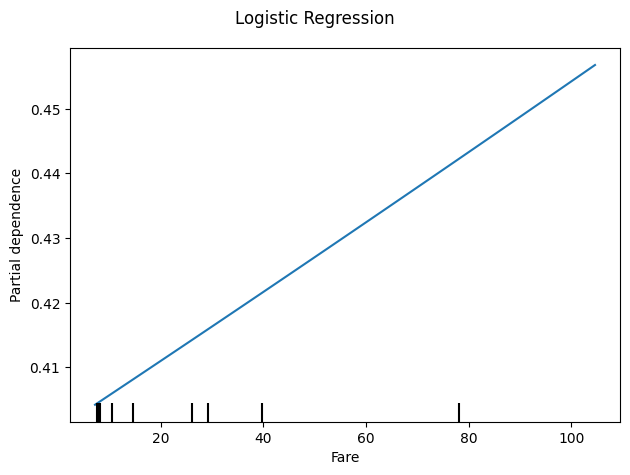

Partial Dependence — KNN


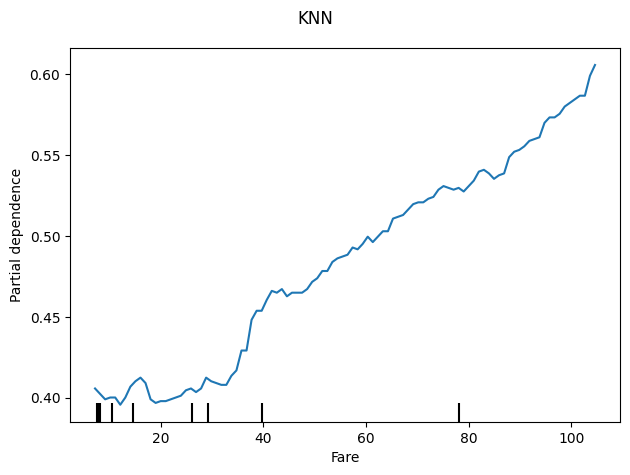

Partial Dependence — Decision Tree


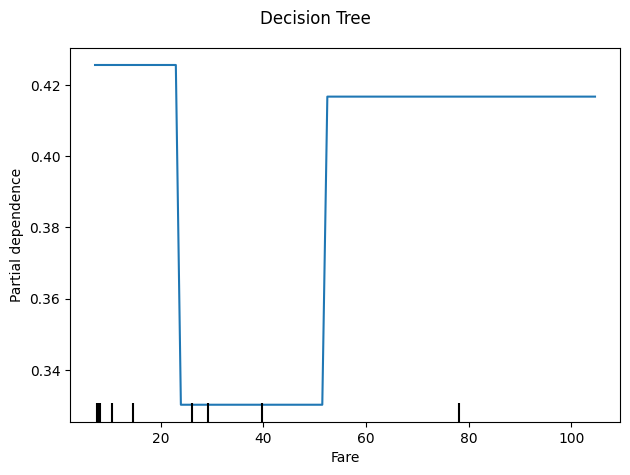

Partial Dependence — SVC


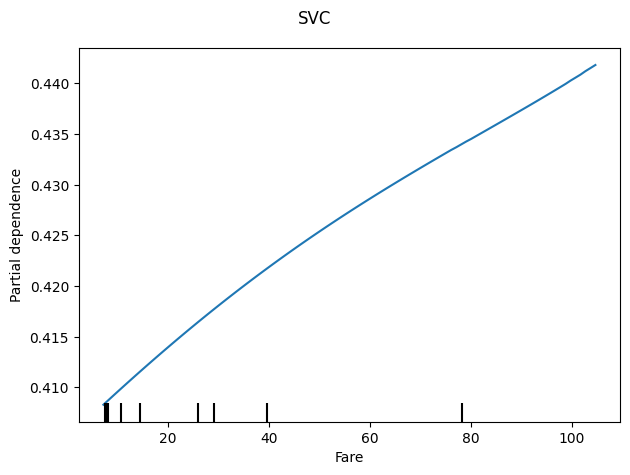

In [36]:
for model_name in models:
    print(f"Partial Dependence — {model_name}")
    PartialDependenceDisplay.from_estimator(pipelines[model_name], X_test, features=['Fare'])
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()